In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
import random

## File Reading

In [4]:
def unpack_data(paired_list):
    labels = [label for label, _ in paired_list]
    data = [features for _, features in paired_list]
    return labels, data

In [5]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

1


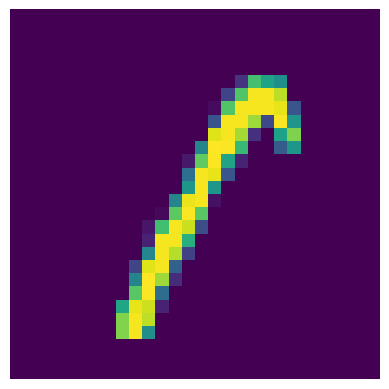

In [8]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [9]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    # only use digits 1–8, and only take 400 of each
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


In [12]:
def error_fractions(p_output, truths):
    wrong_answer_count = 0

    for i in range(len(p_output)):
        if p_output[i] != truths[i]:
            wrong_answer_count += 1
    
    return wrong_answer_count/len(truths)

def positives_counter(p_output, truths):
    true_positives = 0
    false_positives = 0
    true_negatives = 0
    false_negatives = 0

    for i in range(len(p_output)):
        if p_output[i] == 1 and truths[i] == 1:
            true_positives += 1
        
        elif p_output[i] == 0 and truths[i] == 0:
            true_negatives += 1

        elif p_output[i] == 1 and truths[i] == 0:
            false_positives += 1
        
        elif p_output[i] == 0 and truths[i] == 1:
            false_negatives += 1

    return (true_positives, true_negatives, false_positives, false_negatives)

def precision_score(p_output, truths):
    true_positives, _, false_positives, _ = positives_counter(p_output, truths)

    return (true_positives / (true_positives + false_positives))

def recall_score(p_output, truths):
    true_positives, _, _, false_negatives = positives_counter(p_output, truths)

    return (true_positives / (true_positives + false_negatives))

def f1_score(p_output, truths):
    prec_score = precision_score(p_output, truths)
    rec_score = recall_score(p_output, truths)

    return (2 * ((prec_score * rec_score) / (prec_score + rec_score)))

## The Perceptron(s)

In [11]:
# One for each number
w0 = np.random.uniform(0, 0.5, size=785)  
w1 = np.random.uniform(0, 0.5, size=785)  
w2 = np.random.uniform(0, 0.5, size=785)  
w3 = np.random.uniform(0, 0.5, size=785)  
w4 = np.random.uniform(0, 0.5, size=785)  
w5 = np.random.uniform(0, 0.5, size=785)  
w6 = np.random.uniform(0, 0.5, size=785)  
w7 = np.random.uniform(0, 0.5, size=785)  
w8 = np.random.uniform(0, 0.5, size=785)  
w9 = np.random.uniform(0, 0.5, size=785)  

def perceptron_run(number_array, w):
    x0 = 1
    input_array = np.insert(number_array, 0, x0) 
    
    summation = np.dot(w, input_array) 

    # Activation function (step)
    output = 1 if summation > 0 else 0

    return output

In [16]:
training_data_copy = []

# Perceptron 1 (w0)
training_data_copy = [
    (1 if label == 0 else 0, features.copy()) 
    for label, features in combined_train_data
]

testing_data_copy = [
    (1 if label == 0 else 0, features.copy())
    for label, features in combined_test_data
]

In [19]:
lr = 0.01
num_epochs = 1000
error_frac_threshold = 0.001
error_frac = 1.00

epoch_number = 0
while(epoch_number < num_epochs) and (error_frac > error_frac_threshold):
    perc_outputs = []
    print(f"Epoch number {epoch_number + 1}", end=' ')

    ones  = [item for item in training_data_copy if item[0] == 1]
    zeros = [item for item in training_data_copy if item[0] == 0]

    sampled_zeros = random.sample(zeros, len(ones))

    balanced_data = sampled_zeros + ones
    random.shuffle(balanced_data)
    balanced_labels = [item[0] for item in balanced_data]

    for index in range(len(balanced_data)):
        perceptron_output = perceptron_run(balanced_data[index][1], w0)
        perc_outputs.append(perceptron_output)

        error = balanced_labels[index] - perceptron_output

        w0 = w0 + (lr * (error) * (np.insert(balanced_data[index][1], 0, 1)))
        w0[0] = w0[0] + (lr * error)

    error_frac = error_fractions(perc_outputs, balanced_labels)
    epoch_number += 1

    print(f"Error fraction: {error_frac}", end=' ')
    print(f"Length of Data: {len(balanced_data)}", end='\n')

Epoch number 1 Error fraction: 0.2 Length of Data: 800
Epoch number 2 Error fraction: 0.06375 Length of Data: 800
Epoch number 3 Error fraction: 0.055 Length of Data: 800
Epoch number 4 Error fraction: 0.0425 Length of Data: 800
Epoch number 5 Error fraction: 0.04375 Length of Data: 800
Epoch number 6 Error fraction: 0.0275 Length of Data: 800
Epoch number 7 Error fraction: 0.04375 Length of Data: 800
Epoch number 8 Error fraction: 0.02625 Length of Data: 800
Epoch number 9 Error fraction: 0.03 Length of Data: 800
Epoch number 10 Error fraction: 0.025 Length of Data: 800
Epoch number 11 Error fraction: 0.01875 Length of Data: 800
Epoch number 12 Error fraction: 0.02875 Length of Data: 800
Epoch number 13 Error fraction: 0.02125 Length of Data: 800
Epoch number 14 Error fraction: 0.02625 Length of Data: 800
Epoch number 15 Error fraction: 0.025 Length of Data: 800
Epoch number 16 Error fraction: 0.0125 Length of Data: 800
Epoch number 17 Error fraction: 0.02125 Length of Data: 800
Epoch

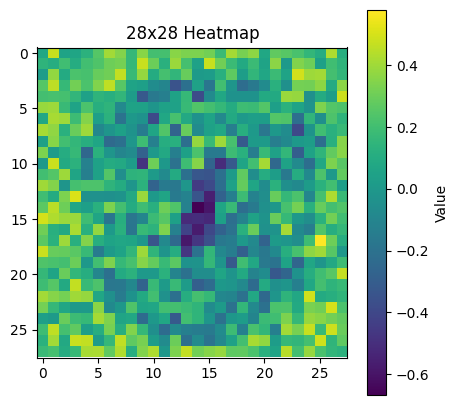

In [22]:
w_matrix = w0[1:].reshape(28, 28).T

plt.figure(figsize=(5, 5))
plt.imshow(w_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('28x28 Heatmap')
plt.show()

In [26]:
perceptron_outputs = []
true_outputs = []

# With the train set
for label, number in testing_data_copy:
    perceptron_outputs.append(perceptron_run(number_array=number, w=w0))
    true_outputs.append(label)

train_error_frac = error_fractions(perceptron_outputs, true_outputs)
print(f"Error Fraction: {error_fractions(perceptron_outputs, true_outputs)}")

train_true_positives, train_true_negatives, train_false_positives, train_false_negatives = positives_counter(perceptron_outputs, true_outputs)
print(f"True positives: {train_true_positives}, True negatives: {train_true_negatives}, False positives: {train_false_positives}, False negatives: {train_false_negatives}")

train_prec_score = precision_score(perceptron_outputs, true_outputs)
print(f"Precision score: {train_prec_score}")

train_rec_score = recall_score(perceptron_outputs, true_outputs)
print(f"Recall score: {recall_score(perceptron_outputs, true_outputs)}")

train_f1_score = f1_score(perceptron_outputs, true_outputs)
print(f"F1 score: {f1_score(perceptron_outputs, true_outputs)}")

Error Fraction: 0.013
True positives: 93, True negatives: 894, False positives: 6, False negatives: 7
Precision score: 0.9393939393939394
Recall score: 0.93
F1 score: 0.9346733668341709
